###Importando as funções

#TESTE DE VIDA ACELERADO

### Instalando bibliotecas para análise de sobrevivência

In [ ]:
pip install --upgrade lifelines

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import LogNormalAFTFitter, KaplanMeierFitter
import scipy.stats as stats

##Inserir dados

In [58]:
import numpy as np
import pandas as pd

# Configuração do seed para reprodutibilidade
np.random.seed(42)
n = 200

# Temperatura em Celsius e Kelvin
temperatura_celsius = np.random.uniform(70, 120, n)  # Temperatura em °C
temperatura_kelvin = temperatura_celsius + 273.15

# Transformação Arrhenius com normalização
arrhenius_term = 1 / temperatura_kelvin  # linear em 1/K
arrhenius_term_normalized = (arrhenius_term - arrhenius_term.mean()) / arrhenius_term.std() # para ajsutar a escala dos dados

# Simulação de tempos de falha com dependência Arrhenius
tempo_falha_base = np.random.lognormal(mean=np.log(10), sigma=0.5, size=n)
# Garantindo que os tempos de falha sejam estritamente positivos
tempo_falha = tempo_falha_base * (arrhenius_term_normalized + abs(arrhenius_term_normalized.min()) + 1e-6)

# Indicador de censura (70% de falhas observadas)
censura = np.random.binomial(1, 0.7, n)  # 1 = falha observada, 0 = censura

# Criando o DataFrame
df = pd.DataFrame({
    "temperature_celsius": temperatura_celsius,
    "temperature_kelvin": temperatura_kelvin,
    "arrhenius_term": arrhenius_term,
    "arrhenius_term_normalized": arrhenius_term_normalized,
    "time_to_failure": tempo_falha,
    "event": censura  # 1 para falha observada, 0 para censura
})
# Visualizando os 5 primeiros registros
print(df.head())



   temperature_celsius  temperature_kelvin  arrhenius_term  \
0            88.727006          361.877006        0.002763   
1           117.535715          390.685715        0.002560   
2           106.599697          379.749697        0.002633   
3            99.932924          373.082924        0.002680   
4            77.800932          350.950932        0.002849   

   arrhenius_term_normalized  time_to_failure  event  
0                   0.337803        14.079302      1  
1                  -1.532055         1.215625      0  
2                  -0.855649         9.084704      1  
3                  -0.423846         8.510848      1  
4                   1.127262        70.346686      1  


###Curva de kaplan Meier para as diferentes temperaturas

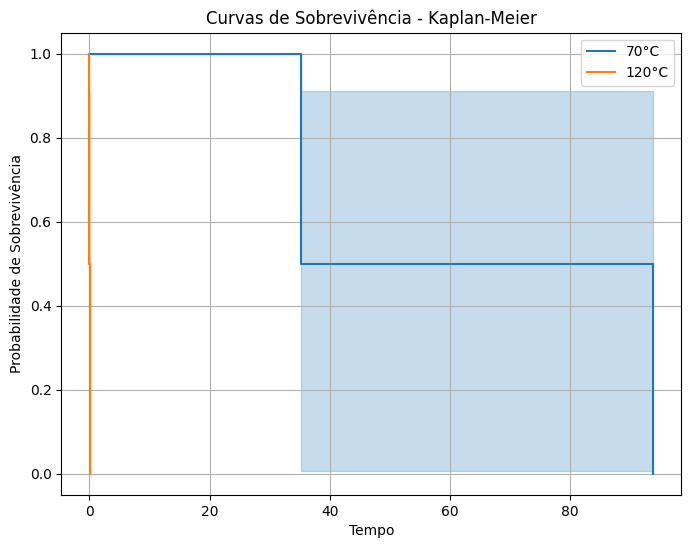

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Criar o estimador
kmf = KaplanMeierFitter()

# Definir grupos por faixa de temperatura (ajuste os limites conforme seus dados)
grupo_70 = df[(df['temperature_celsius'] >= 69) & (df['temperature_celsius'] <= 71)]
grupo_120 = df[(df['temperature_celsius'] >= 119) & (df['temperature_celsius'] <= 121)]

# Plotando as curvas de sobrevivência
plt.figure(figsize=(8, 6))

# Grupo 70 °C
kmf.fit(grupo_70['time_to_failure'], event_observed=grupo_70['event'], label="70°C")
kmf.plot_survival_function()

# Grupo 120 °C
kmf.fit(grupo_120['time_to_failure'], event_observed=grupo_120['event'], label="120°C")
kmf.plot_survival_function()

# Personalização
plt.title("Curvas de Sobrevivência - Kaplan-Meier")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.legend()
plt.show()


🔍 Interpretação detalhada:
Grupo 120°C (laranja):

A curva cai de 1 para 0 quase imediatamente — indicando que todas ou quase todas as falhas ocorrem muito cedo.

Isso é esperado em testes de estresse térmico: altas temperaturas aceleram o processo de falha.

A sobrevivência tende a zero rapidamente → indica um alto risco de falha em curto prazo.

Grupo 70°C (azul):

A curva mantém-se em 1 por um tempo considerável, e depois cai de forma abrupta.

Isso sugere que a maioria dos itens sobrevive por bastante tempo, e então ocorrem algumas falhas.

A curva parece ter menos eventos de falha ou talvez censura, já que permanece estável por bastante tempo.

O sombreado azul representa o intervalo de confiança (IC 95%) da curva de sobrevivência.

###Teste de Log-Rank para comparar as curvas de sobrevivência

In [61]:
from lifelines.statistics import logrank_test

# Selecionar os grupos com base na temperatura original (com uma margem de tolerância)
grupo_70 = df[(df['temperature_celsius'] >= 69) & (df['temperature_celsius'] <= 71)]
grupo_120 = df[(df['temperature_celsius'] >= 119) & (df['temperature_celsius'] <= 121)]

# Verificar se ambos os grupos têm dados
if len(grupo_70) == 0 or len(grupo_120) == 0:
    print("Erro: Um dos grupos está vazio. Ajuste os limites de temperatura.")
else:
    # Aplicar o teste de log-rank
    resultado = logrank_test(
        grupo_70['time_to_failure'], grupo_120['time_to_failure'],
        event_observed_A=grupo_70['event'],
        event_observed_B=grupo_120['event']
    )

    print("\nResultado do Teste de Log-Rank entre 70°C e 120°C:")
    print(f"Estatística do teste: {resultado.test_statistic:.4f}")
    print(f"Valor-p: {resultado.p_value:.4f}")

    if resultado.p_value < 0.05:
        print("Rejeitamos a hipótese nula: As curvas de sobrevivência são significativamente diferentes.")
    else:
        print("Não rejeitamos a hipótese nula: Não há diferença significativa entre as curvas de sobrevivência.")




Resultado do Teste de Log-Rank entre 70°C e 120°C:
Estatística do teste: 4.2632
Valor-p: 0.0389
Rejeitamos a hipótese nula: As curvas de sobrevivência são significativamente diferentes.


#Modelo Arrhenius-Weibull

###Ajuste do modelo Arrhenius-Weibull

In [62]:
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustando o modelo Weibull AFT (com censura)
aft_w = WeibullAFTFitter()
aft_w.fit(df_model, duration_col="time_to_failure", event_col="event", formula="arrhenius_term_normalized")

# Resumo do modelo
aft_w.print_summary()


<lifelines.WeibullAFTFitter: fitted with 200 total observations, 56 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'event'
   number of observations = 200
number of events observed = 144
           log-likelihood = -549.42
         time fit was run = 2025-08-31 14:27:24 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                  
lambda_ Intercept                  3.00     20.10      0.06            2.89            3.11               18.01               22.43
        arrhenius_term_normalized  0.96      2.60      0.07            0.83            1.09                2.28                2.96
rho_    Intercept                  0.41      1.50      0.06            0.28            0.53                1.33                1.70

                                   cmp to     z      p  -log2(p)
param   covariate                                               
lambda_ Intercept                    0.00 53.66 <0.005       inf
        arrhenius_term_normalized    0.00 14.36 <0.005    152.99
rho_    Intercept                    0.00  6.53 <0.005     33.81
---
Concordance = 0.85
AIC = 1104.85
log-likelihood ratio test = 142.51 on 1 df
-log2(p) of ll-ratio test = 106.71

Interpretação:

O efeito da temperatura é estatisticamente significativo com z = 14.36 e p < 0.005

O índice de concordância = 0.85 indica que o modelo tem boa capacidade preditiva para ordenação dos tempos de falha.

Um aumento de 1 unidade no valor normalizado do termo de Arrhenius (1/T)
(ou seja, queda na temperatura), leva a um aumento de 2.6 vezes no tempo de vida esperado.

A temperatura mais baixa aumenta a vida útil — coerente com o modelo de Arrhenius.

rho_= 0.41 < 1 (p<0.005) é significativo e indica uma taxa de falha decrescente com o tempo



###Curva de Sobrevivência

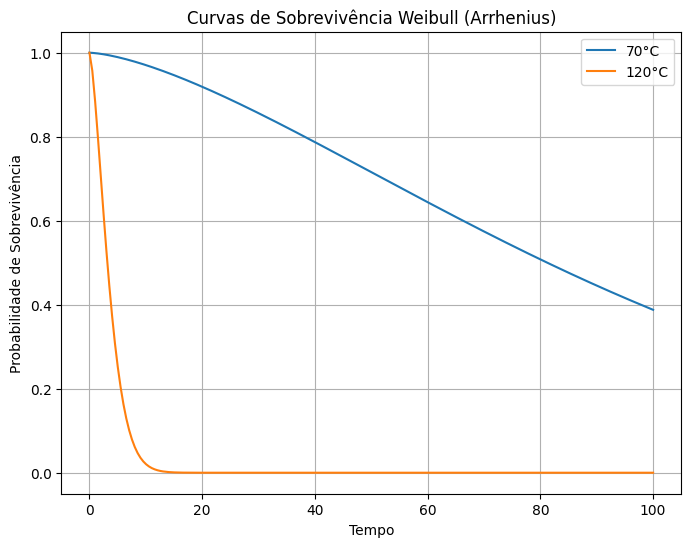

In [63]:
# Pegar média e desvio padrão usados na normalização original
arrh_mean = df['arrhenius_term'].mean()
arrh_std = df['arrhenius_term'].std()

# Temperaturas para plotar
temps_to_plot = [70, 120]  # em Celsius
temps_K = [t + 273.15 for t in temps_to_plot]
inv_temps = [1 / t for t in temps_K]

# Normalizando os valores de arrhenius_term
inv_temps_normalized = [(x - arrh_mean) / arrh_std for x in inv_temps]

# Plotar curvas de sobrevivência
plt.figure(figsize=(8, 6))
for norm_val, T in zip(inv_temps_normalized, temps_to_plot):
    surv = aft_w.predict_survival_function(
        pd.DataFrame({'arrhenius_term_normalized': [norm_val]}),
        times=np.linspace(0, 100, 200)
    )
    plt.plot(surv.index, surv.values.flatten(), label=f'{T}°C')

plt.title("Curvas de Sobrevivência Weibull (Arrhenius)")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend()
plt.grid(True)
plt.show()




🌡️ Interpretação por temperatura:

🔵 70°C (linha azul):

Alta sobrevivência ao longo do tempo. Mesmo após 100 unidades de tempo, cerca de 40% dos itens continuam operacionais.

Curva suavemente decrescente → baixa taxa de falha.

**Interpretação**:
Em 70°C, os mecanismos de falha térmica são pouco ativados. Isso simula condições normais de uso ou ambientes suaves, onde o item é muito mais durável.

🟠 120°C (linha laranja):

Queda abrupta da sobrevivência. A maioria dos itens falha em menos de 10 unidades de tempo.

Após 20 unidades, praticamente nenhum item sobrevive.

**Interpretação**:
A 120°C, a degradação térmica acelera muito os mecanismos de falha, o que está em conformidade com o modelo de Arrhenius (a taxa de reação cresce exponencialmente com a temperatura).

🧠 Conclusão física:
Altas temperaturas aceleram os mecanismos de falha, exatamente como previsto pelo modelo Arrhenius.

Forma das curvas: Weibull parâmetro de forma ρ < 1

Decaimento rápido no início e uma “cauda” longa nas curvas de temperaturas mais baixas.

Isso está de acordo com o parâmetro de forma β = 0.41 < 1 estimado no modelo → indicando um comportamento de falha com maior taxa de falha no início e menor risco conforme o tempo passa (para os sobreviventes).

###Curva da Função de Risco

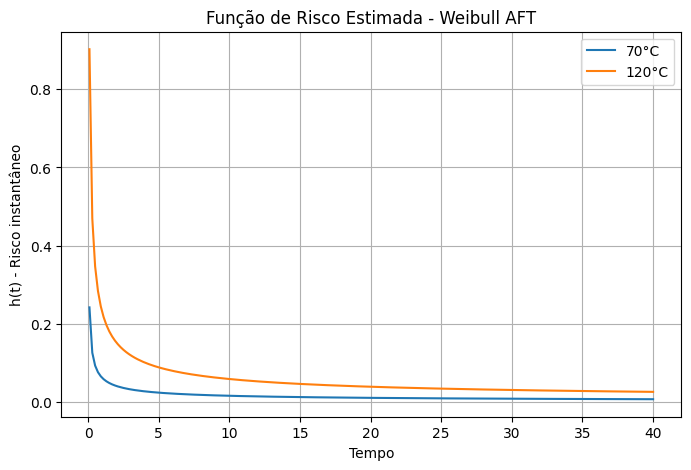

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetro de forma estimado (rho_)
rho = aft_w.params_['rho_']['Intercept']

# Temperaturas alvo
T_target = np.array([70, 120])  # em Celsius
T_K = T_target + 273.15         # Converter para Kelvin
inv_temp = 1 / T_K              # 1/T
inv_temp_norm = (inv_temp - arrh_mean) / arrh_std  # Normalizar

# Estimar o log da escala (lambda_) para cada temperatura
lambda_log = (aft_w.params_['lambda_']['Intercept'] +
              aft_w.params_['lambda_']['arrhenius_term_normalized'] * inv_temp_norm)
lambda_ = np.exp(lambda_log)

# Função de risco de Weibull para cada temperatura
t_vals = np.linspace(0.1, 40, 200)

plt.figure(figsize=(8, 5))

for i, T in enumerate(T_target):
    h_t = (rho / lambda_[i]) * (t_vals / lambda_[i])**(rho - 1)
    plt.plot(t_vals, h_t, label=f"{T}°C")

# Gráfico
plt.title("Função de Risco Estimada - Weibull AFT")
plt.xlabel("Tempo")
plt.ylabel("h(t) - Risco instantâneo")
plt.grid(True)
plt.legend()
plt.show()



**O que esse gráfico mostra?**

Decaimento do risco com o tempo:

Em ambos os casos, o risco cai com o tempo, típico de modelo Weibull com ρ<1:

Representa falhas infantis — defeitos iniciais falham cedo, sobreviventes são mais robustos.

**Influência da temperatura:**

A temperatura mais alta (120°C) tem risco inicial mais de 3x maior que a de 70°C. Ou seja, o ambiente mais quente acelera falhas (como o modelo de Arrhenius pressupõe).

🔵 Azul: 70°C

Risco inicial baixo e decrescente lentamente. Produto confiável, risco de falha baixo e persistente

🟠 Laranja:120°C

Risco inicial muito alto, caindo rapidamente. Produto falha rápido sob estresse térmico — típica de aceleração de falhas

##Validação do Modelo

###Sobreposição da curva de Kaplan-Meier com a curva estimada pelo modelo Arrhenius-Weibull AFT

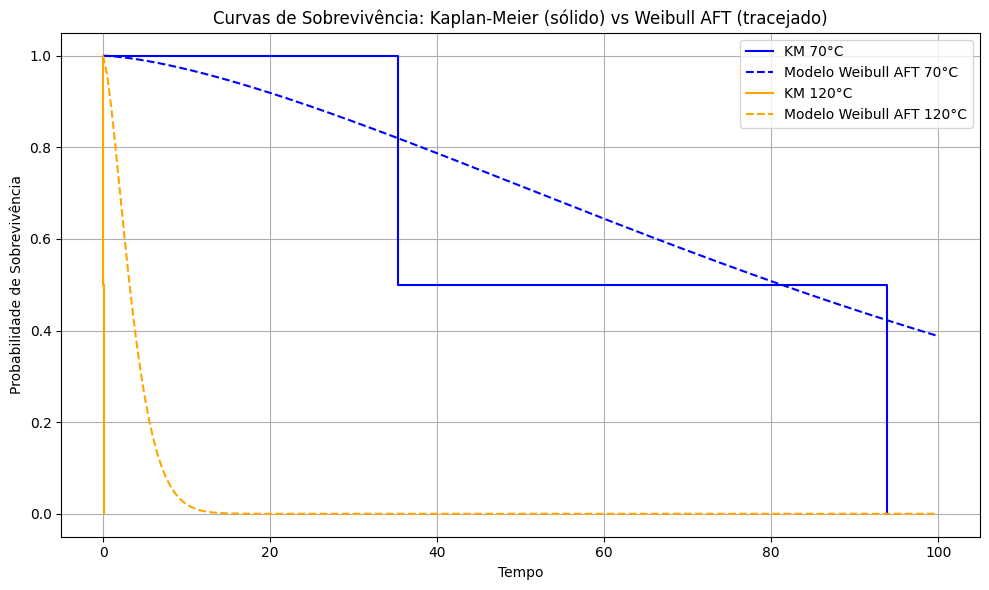

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Recalcular média e desvio da normalização (se ainda não tiver feito)
arrh_mean = df['arrhenius_term'].mean()
arrh_std = df['arrhenius_term'].std()

# Grupos por temperatura (ajuste os limites se necessário)
grupo_70 = df[(df['temperature_celsius'] >= 69) & (df['temperature_celsius'] <= 71)]
grupo_120 = df[(df['temperature_celsius'] >= 119) & (df['temperature_celsius'] <= 121)]

# Temperaturas para predição
temps = [70, 120]
colors = ['blue', 'orange']  # Azul para 70, laranja para 120

# Inicializar o gráfico
plt.figure(figsize=(10, 6))

# Loop sobre as temperaturas e os grupos
for T, grupo, color in zip(temps, [grupo_70, grupo_120], colors):
    # Kaplan-Meier empírica
    kmf = KaplanMeierFitter()
    kmf.fit(grupo['time_to_failure'], event_observed=grupo['event'], label=f'KM {T}°C')
    kmf.plot_survival_function(ci_show=False, color=color, linestyle='-')

    # Termo de Arrhenius normalizado para o modelo
    T_K = T + 273.15
    inv_temp = 1 / T_K
    inv_temp_norm = (inv_temp - arrh_mean) / arrh_std

    # Curva predita pelo modelo
    times = np.linspace(0, 100, 200)
    surv_pred = aft_w.predict_survival_function(
        pd.DataFrame({'arrhenius_term_normalized': [inv_temp_norm]}),
        times=times
    )
    plt.plot(
        surv_pred.index,
        surv_pred.values.flatten(),
        linestyle='--',
        color=color,
        label=f'Modelo Weibull AFT {T}°C'
    )

# Finalização do gráfico
plt.title("Curvas de Sobrevivência: Kaplan-Meier (sólido) vs Weibull AFT (tracejado)")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


🔵 70°C

Linha sólida azul: Kaplan-Meier (dados reais)

Linha tracejada azul: Curva predita pelo modelo Weibull AFT

✅ O modelo Weibull acompanha razoavelmente bem a curva empírica, o que indica um ajuste adequado nesse intervalo de temperatura.

🟠 120°C

Linha sólida laranja: Kaplan-Meier (dados reais)

Linha tracejada laranja: Curva predita pelo modelo Weibull AFT

⚠️ Aqui, vemos que:

A curva de Kaplan-Meier cai abruptamente para 0 logo no início, sugerindo falhas muito rápidas nessa temperatura.

A curva do modelo Weibull também cai rapidamente, mas de forma mais suave e contínua, não refletindo totalmente a realidade abrupta observada

**Interpretação geral:**

O modelo captura a tendência geral: maior temperatura → menor sobrevivência.

Mas, para 120°C, há indício de que:

Os dados podem ser muito concentrados no tempo inicial.

Ou o modelo pode não estar capturando bem a aceleração provocada pela alta temperatura.

###Análise de Resíduos

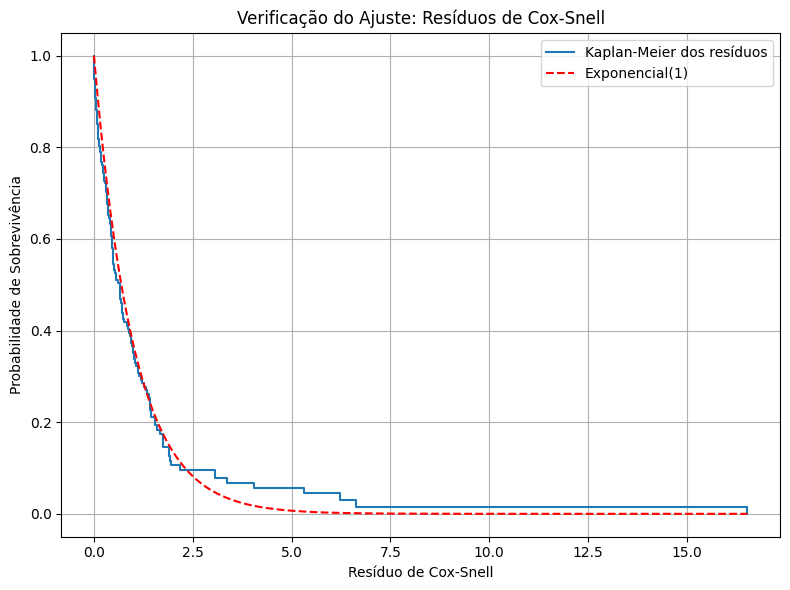

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Calculando a função de sobrevivência estimada para o modelo ajustado
survival_function = aft_w.predict_survival_function(df[["arrhenius_term_normalized"]])

# Calculando os resíduos de Cox-Snell (baseados na fórmula: -log(S(t)))
residuos = -np.log(survival_function.iloc[:, 0])

# Ajustar Kaplan-Meier sobre os resíduos
kmf = KaplanMeierFitter()
kmf.fit(residuos, event_observed=df["event"])

# Plotar curva KM dos resíduos vs curva teórica exponencial(1)
plt.figure(figsize=(8, 6))
kmf.plot_survival_function(ci_show=False, label="Kaplan-Meier dos resíduos")

# Curva teórica Exponencial(1): S(t) = exp(-t)
t_vals = np.linspace(0, residuos.max(), 200)
plt.plot(t_vals, np.exp(-t_vals), label="Exponencial(1)", linestyle="--", color="red")

# Gráfico final
plt.title("Verificação do Ajuste: Resíduos de Cox-Snell")
plt.xlabel("Resíduo de Cox-Snell")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




O modelo está corretamente especificado, pois os resíduos estão se comportando como se fossem extraídos de uma distribuição Exponencial(1).

A curva azul segue razoavelmente bem a curva vermelha.

Isso sugere que o modelo Arrhenius-Weibull AFT está bem ajustado aos dados, embora possa haver pequenas discrepâncias nas caudas (o que é comum).

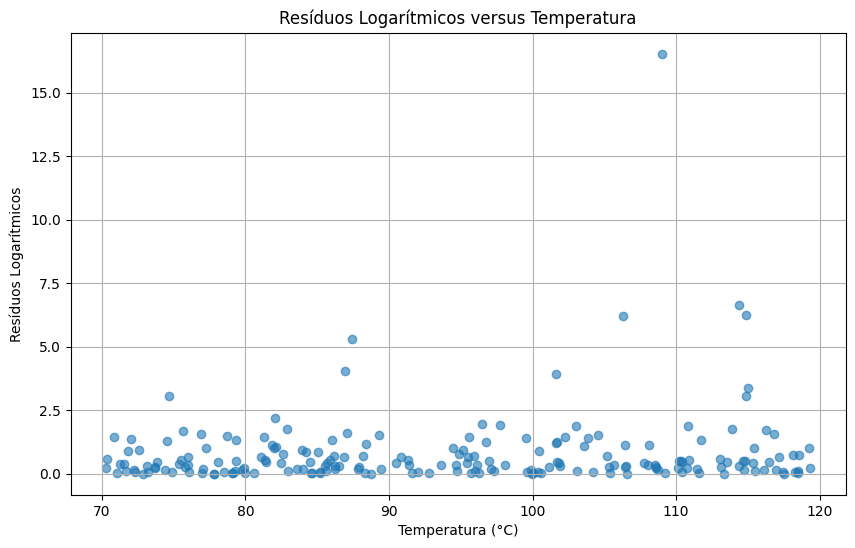

In [82]:
# Resíduos versus Temperatura
plt.figure(figsize=(10, 6))
plt.scatter(df["temperature_celsius"], residuos, alpha=0.6)
plt.title("Resíduos Logarítmicos versus Temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Resíduos Logarítmicos")
plt.grid()
plt.show()

Interpretação:

Boa parte dos resíduos está próxima de zero, o que é esperado se o modelo ajusta bem a maior parte dos dados.

Há resíduos muito grandes em algumas observações de temperatura elevada (>100°C), o que pode indicar que o modelo superestima ou subestima o tempo de falha nessas condições.

Não há um padrão sistemático evidente com a temperatura (ex: não é crescente ou decrescente), mas a variância parece aumentar com a temperatura, o que pode indicar:

Algum efeito heterocedástico (variância não constante)

Ou que o modelo não captura bem a relação em altas temperaturas

Em geral, o modelo parece estar razoavelmente bem ajustado na faixa de temperaturas médias e baixas.

Pode haver necessidade de:

Investigar os outliers → são medições erradas ou comportamentos reais?

Tentar outras distribuições (como log-normal) para ver se explicam melhor o padrão em altas temperaturas.

###Previsão sob condições normais de uso (25°C)

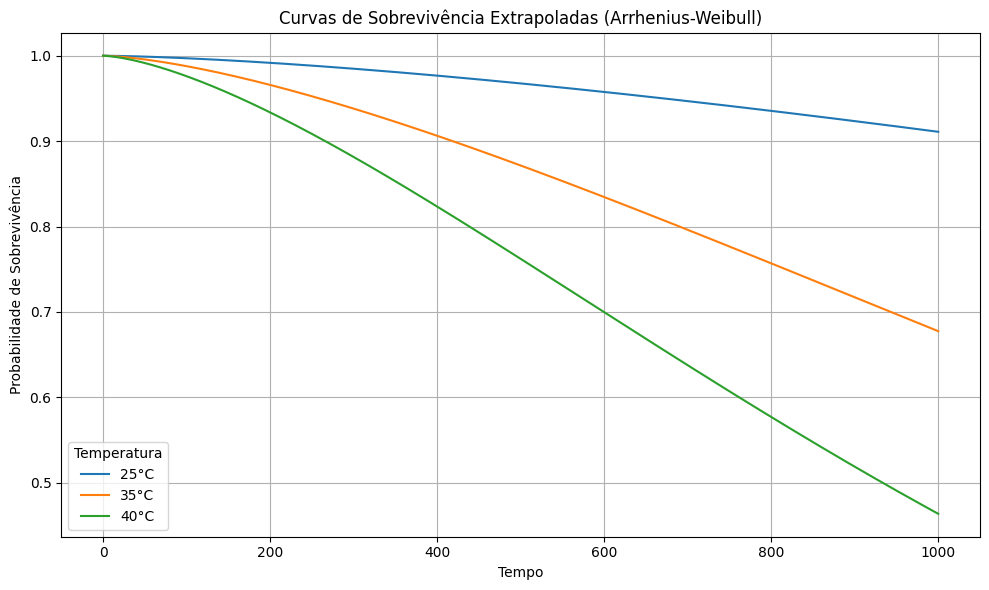

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Temperaturas normais de uso (em °C)
temps_celsius = [25, 35, 40]
temps_K = [t + 273.15 for t in temps_celsius]

# Termo de Arrhenius
inv_temps = [1 / T for T in temps_K]

# Normalização com média e desvio padrão usados no modelo
arrh_mean = df['arrhenius_term'].mean()
arrh_std = df['arrhenius_term'].std()
inv_temps_norm = [(x - arrh_mean) / arrh_std for x in inv_temps]

# Intervalo de tempo para prever (ajuste conforme necessário)
times = np.linspace(0, 1000, 500)

# Plotar todas as curvas no mesmo gráfico
plt.figure(figsize=(10, 6))
for norm_val, temp in zip(inv_temps_norm, temps_celsius):
    surv = aft_w.predict_survival_function(
        pd.DataFrame({'arrhenius_term_normalized': [norm_val]}),
        times=times
    )
    plt.plot(surv.index, surv.values.flatten(), label=f'{temp}°C')

# Personalização
plt.title("Curvas de Sobrevivência Extrapoladas (Arrhenius-Weibull)")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend(title="Temperatura")
plt.grid(True)
plt.tight_layout()
plt.show()



Interpretação por temperatura

Curva azul (25°C):

A mais lenta a decair → indica que o produto/dado testado tem maior tempo de vida esperado em temperatura ambiente.

A sobrevida se mantém acima de 90% mesmo após 1000 dias

Curva laranja (35°C):

Decai mais rapidamente que a de 25°C e indica redução moderada na durabilidade quando a temperatura é aumentada para 35°C.

Curva verde (40 °C):

A mais inclinada → sobrevivência cai mais rápido.

Com 1000 dias, a probabilidade de sobrevivência já está abaixo de 50%.

Indica que o aumento de temperatura acelera significativamente o desgaste/falha.

###Cálculo do tempo médio de vida em dias

In [89]:
for norm_val, temp in zip(inv_temps_norm, temps_celsius):
    mttf = aft_w.predict_expectation(pd.DataFrame({'arrhenius_term_normalized': [norm_val]}))
    mttf_dias = mttf.values[0]
    mttf_meses = mttf_dias / 30.44  # média de dias por mês
    mttf_anos = mttf_dias / 365.25  # média de dias por ano
    print(f"Temperatura {temp}°C → Tempo médio de vida estimado: {mttf_meses:.2f} meses ({mttf_anos:.2f} anos)")



Temperatura 25°C → Tempo médio de vida estimado: 144.01 meses (12.00 anos)
Temperatura 35°C → Tempo médio de vida estimado: 55.59 meses (4.63 anos)
Temperatura 40°C → Tempo médio de vida estimado: 35.33 meses (2.94 anos)


**CONCLUSÃO**

O sistema/modelo é consistente com a teoria de degradação térmica: maior temperatura → menor tempo de vida.

As curvas indicam que operar o produto a 25°C resulta em longevidade significativamente maior do que a 40°C.

Isso é útil para extrapolar testes acelerados para uso real, prever falhas e ajustar garantias.

#Modelo Arrhenius-Lognormal

###Ajuste do modelo

In [97]:
from lifelines import LogNormalAFTFitter

aft = LogNormalAFTFitter()
aft.fit(df, duration_col="time_to_failure", event_col="event", formula="arrhenius_term_normalized")
aft.print_summary()


<lifelines.LogNormalAFTFitter: fitted with 200 total observations, 56 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'event'
   number of observations = 200
number of events observed = 144
           log-likelihood = -613.97
         time fit was run = 2025-08-31 15:14:45 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                  
mu_    Intercept                  2.77     15.98      0.10            2.57            2.97               13.03               19.59
       arrhenius_term_normalized  1.15      3.14      0.10            0.94            1.35                2.57                3.84
sigma_ Intercept                  0.30      1.35      0.06            0.19            0.42                1.20                1.52

                                  cmp to     z      p  -log2(p)
param  covariate                                               
mu_    Intercept                    0.00 26.67 <0.005    518.02
       arrhenius_term_normalized    0.00 11.19 <0.005     94.17
sigma_ Intercept                    0.00  5.11 <0.005     21.56
---
Concordance = 0.85
AIC = 1233.94
log-likelihood ratio test = 94.48 on 1 df
-log2(p) of ll-ratio test = 71.77

###Curva de Sobrevivência Estimada para Modelo Arrhenius-Lognormal

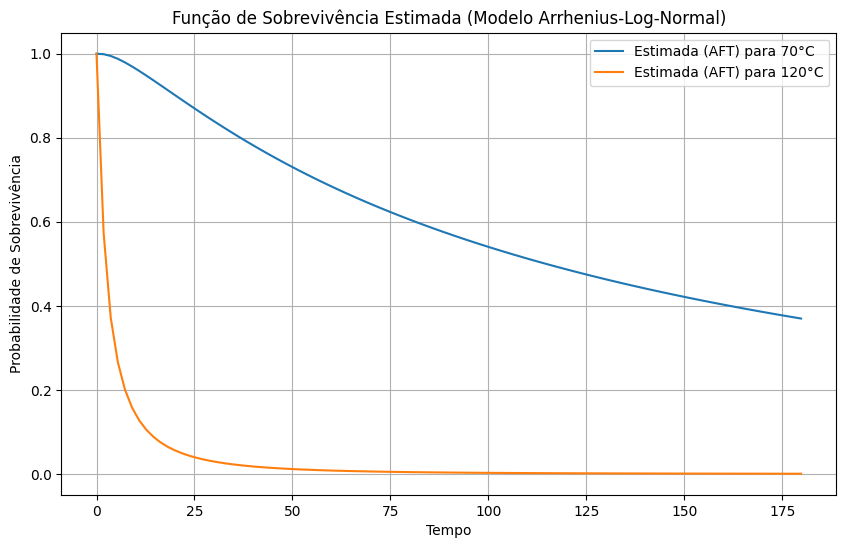

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# Definição do intervalo de tempo para previsão
time_range = np.linspace(df["time_to_failure"].min(), df["time_to_failure"].max(), 100)

# Previsão da função de sobrevivência para diferentes temperaturas
survival_estimates_70 = aft.predict_survival_function(
    pd.DataFrame({"arrhenius_term_normalized": [(1 / (70 + 273.15) - arrhenius_term.mean()) / arrhenius_term.std()]}),
    times=time_range
)

survival_estimates_120 = aft.predict_survival_function(
    pd.DataFrame({"arrhenius_term_normalized": [(1 / (120 + 273.15) - arrhenius_term.mean()) / arrhenius_term.std()]}),
    times=time_range
)

# Plot da função de sobrevivência
plt.figure(figsize=(10, 6))
plt.title("Função de Sobrevivência Estimada (Modelo Arrhenius-Log-Normal)")
plt.plot(time_range, survival_estimates_70.iloc[:, 0], label="Estimada (AFT) para 70°C")
plt.plot(time_range, survival_estimates_120.iloc[:, 0], label="Estimada (AFT) para 120°C")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend()
plt.grid()
plt.show()





Linha azul (70°C):
A curva decresce lentamente, indicando que a probabilidade de sobrevivência permanece relativamente alta por mais tempo. Ou seja, a vida útil é maior nessa temperatura mais baixa. O equipamento tende a durar mais tempo antes de falhar.

Linha laranja (120°C):
A curva cai muito rapidamente, indicando que a probabilidade de sobrevivência diminui rápido. Ou seja, a vida útil é menor nessa temperatura mais alta, e as falhas acontecem muito mais cedo.

###Tabela da Função de Sobrevivência ou Confiabilidade para as diferentes temperatura

In [92]:
print(pd.DataFrame({'temp:70':(survival_estimates_70.iloc[:, 0]), 'temp:120':(survival_estimates_120.iloc[:, 0])}))

             temp:70  temp:120
0.000004    1.000000  1.000000
1.816341    0.998908  0.573776
3.632679    0.994641  0.372104
5.449017    0.987841  0.265673
7.265354    0.979297  0.200856
...              ...       ...
172.552073  0.381475  0.000737
174.368410  0.378528  0.000718
176.184748  0.375619  0.000699
178.001085  0.372746  0.000681
179.817423  0.369910  0.000663

[100 rows x 2 columns]


###Função de Risco

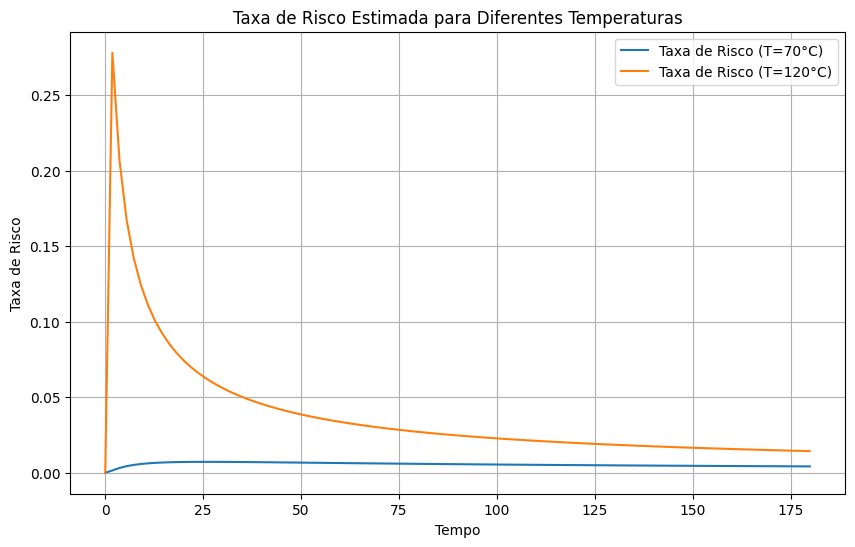

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Temperaturas para comparação
temperatures = [70, 120]
hazards = []

# Estimando a taxa de risco para diferentes temperaturas
for temp in temperatures:
    arrhenius_term_normalized = (1 / (temp + 273.15) - arrhenius_term.mean()) / arrhenius_term.std()  # Normalização

    # Previsão da taxa de risco para cada temperatura
    hazard = aft.predict_hazard(
        pd.DataFrame({"arrhenius_term_normalized": [arrhenius_term_normalized]}),
        times=time_range
    )

    hazards.append(hazard)

# Plotando as taxas de risco para cada temperatura
plt.figure(figsize=(10, 6))
plt.title("Taxa de Risco Estimada para Diferentes Temperaturas")

for i, temp in enumerate(temperatures):
    hazard = hazards[i].iloc[:, 0]  # Selecionando a primeira coluna da previsão
    plt.plot(time_range, hazard, label=f"Taxa de Risco (T={temp}°C)")

plt.xlabel("Tempo")
plt.ylabel("Taxa de Risco")
plt.legend()
plt.grid()
plt.show()





Linha azul (70°C):
A taxa de risco começa muito baixa e sobe lentamente, estabilizando em um valor baixo ao longo do tempo. Isso indica que, para essa temperatura mais baixa, o risco de falha é pequeno e não muda muito com o tempo, sugerindo uma degradação mais lenta e confiável.

Linha laranja (120°C):
A taxa de risco começa alta, atingindo um pico rapidamente, e depois decresce ao longo do tempo, mas ainda permanece bem acima da linha azul. Isso indica que a falha é mais provável logo no início do uso em alta temperatura, com risco elevado de falha precoce, e depois o risco diminui, provavelmente porque os itens mais frágeis já falharam cedo.

###Adequação do Modelo Ajustado

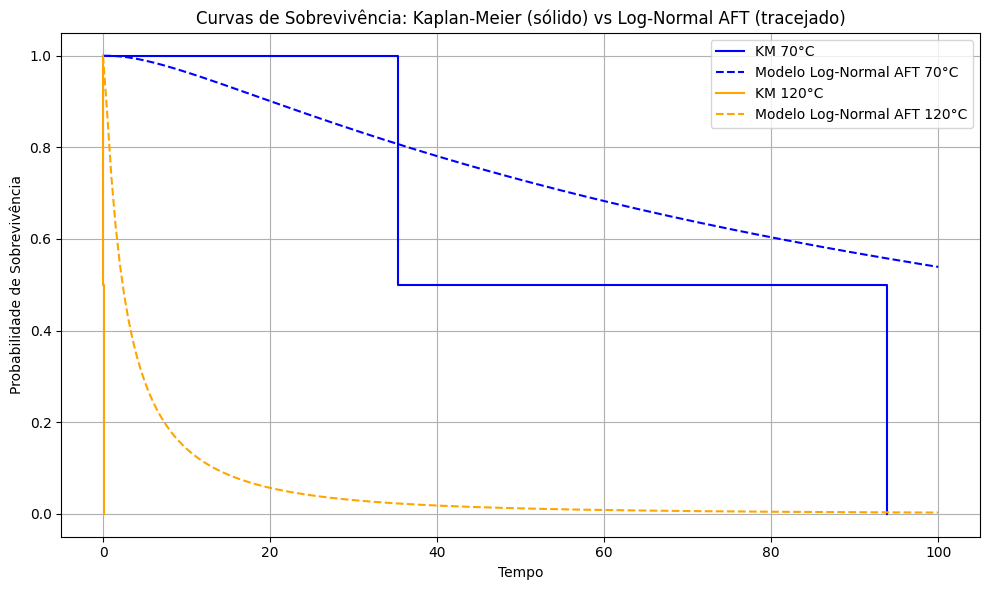

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Recalcular média e desvio da normalização (se ainda não tiver feito)
arrh_mean = df['arrhenius_term'].mean()
arrh_std = df['arrhenius_term'].std()

# Grupos por temperatura (ajuste os limites se necessário)
grupo_70 = df[(df['temperature_celsius'] >= 69) & (df['temperature_celsius'] <= 71)]
grupo_120 = df[(df['temperature_celsius'] >= 119) & (df['temperature_celsius'] <= 121)]

# Temperaturas para predição
temps = [70, 120]
colors = ['blue', 'orange']  # Azul para 70, laranja para 120

# Inicializar o gráfico
plt.figure(figsize=(10, 6))

# Loop sobre as temperaturas e os grupos
for T, grupo, color in zip(temps, [grupo_70, grupo_120], colors):
    # Kaplan-Meier empírica
    kmf = KaplanMeierFitter()
    kmf.fit(grupo['time_to_failure'], event_observed=grupo['event'], label=f'KM {T}°C')
    kmf.plot_survival_function(ci_show=False, color=color, linestyle='-')

    # Termo de Arrhenius normalizado para o modelo
    T_K = T + 273.15
    inv_temp = 1 / T_K
    inv_temp_norm = (inv_temp - arrh_mean) / arrh_std

    # Curva predita pelo modelo
    times = np.linspace(0, 100, 200)
    surv_pred = aft.predict_survival_function(
        pd.DataFrame({'arrhenius_term_normalized': [inv_temp_norm]}),
        times=times

    )
    plt.plot(
        surv_pred.index,
        surv_pred.values.flatten(),
        linestyle='--',
        color=color,
        label=f'Modelo Log-Normal AFT {T}°C'
    )

# Finalização do gráfico
plt.title("Curvas de Sobrevivência: Kaplan-Meier (sólido) vs Log-Normal AFT (tracejado)")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Análise por temperatura:

70°C (linha azul):

KM mostra um declínio em degraus (característico da estimação empírica), indicando as falhas ao longo do tempo.

O modelo Log-Normal suaviza a curva, mostrando uma queda mais gradual e contínua da sobrevivência, que tenta representar a tendência geral dos dados.

120°C (linha laranja):

KM indica que a sobrevivência cai muito rápido no início, sugerindo falhas precoces.

O modelo Log-Normal também indica queda rápida, mas com suavização, mantendo a mesma tendência geral.

**Interpretação geral:**

O modelo Log-Normal AFT ajustado se aproxima razoavelmente bem da curva empírica, especialmente na tendência geral.

Para 120°C, há falhas muito rápidas, indicando vida útil curta sob essa temperatura.

Para 70°C, a vida útil é maior, com quedas graduais e mais espaçadas.

###Gráfico QQ-plot

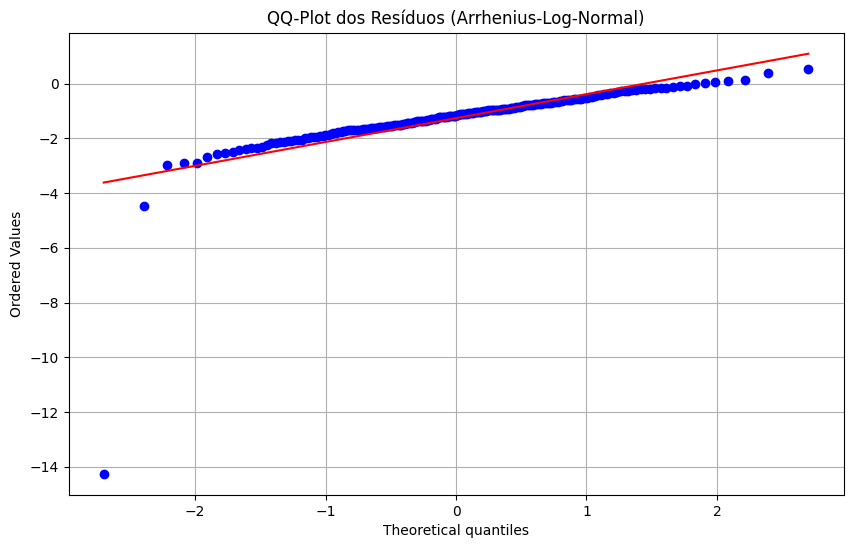

In [101]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

# Ajuste do modelo AFT (Log-Normal) e obtenção das previsões (expectativa)
mu_pred = aft.predict_expectation(df[["arrhenius_term_normalized"]])

# Cálculo dos resíduos logarítmicos
residuals_log = np.log(df["time_to_failure"]) - np.log(mu_pred)

# Gerar o QQ-Plot
fig, ax = plt.subplots(figsize=(10, 6))
probplot(residuals_log, dist="norm", plot=ax)
plt.title("QQ-Plot dos Resíduos (Arrhenius-Log-Normal)")
plt.grid()
plt.show()



Análise desse gráfico:

A maior parte dos pontos se aproxima da linha vermelha, especialmente no centro da distribuição (quantis medianos), indicando um bom ajuste do modelo para a maioria dos dados.

Há alguns pontos distantes da linha nas extremidades inferiores (cauda esquerda), indicando possíveis outliers ou que o modelo subestima a variabilidade extrema para tempos muito baixos.

Isso é comum em dados de sobrevivência, onde eventos precoces ou falhas muito rápidas podem não ser bem modeladas.

**Conclusão:**

O modelo Arrhenius-Log-Normal tem um ajuste razoável aos dados, mas pode apresentar alguma dificuldade em capturar bem os casos extremos.

Para a maioria dos dados, o modelo é adequado.

Se os outliers forem importantes, pode-se considerar métodos robustos ou modelos alternativos.

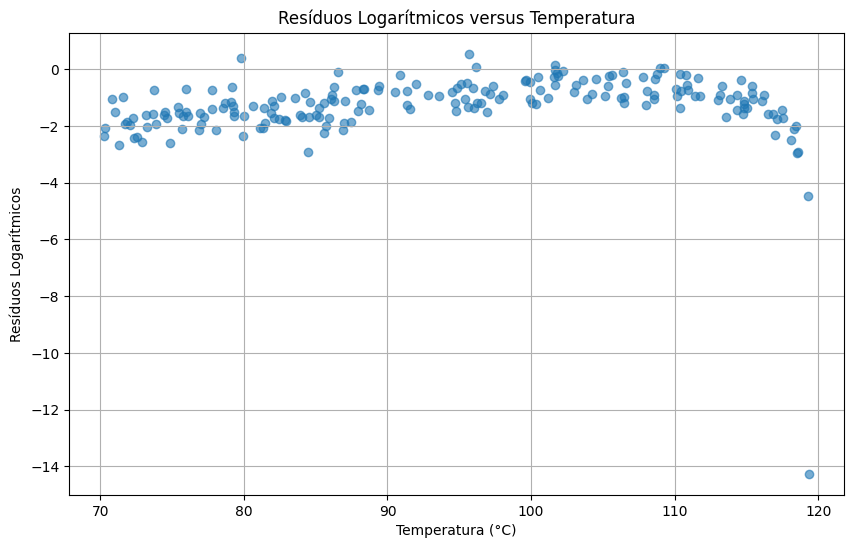

In [102]:
# Resíduos versus Temperatura
plt.figure(figsize=(10, 6))
plt.scatter(df["temperature_celsius"], residuals_log, alpha=0.6)
plt.title("Resíduos Logarítmicos versus Temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Resíduos Logarítmicos")
plt.grid()
plt.show()



Observações deste gráfico:

Os resíduos estão em sua maioria abaixo de zero, indicando que o modelo tende a superestimar os valores reais (os valores previstos são maiores que os observados).

Parece haver uma leve tendência negativa conforme a temperatura aumenta, especialmente perto de 120°C, onde os resíduos são mais negativos.

Alguns resíduos muito grandes (valores muito baixos) indicam erros significativos em pontos específicos, que podem ser outliers ou casos mal modelados.

**Conclusão:**

O modelo apresenta um padrão de resíduos que indica possível viés (superestimação) em algumas temperaturas.

O ajuste pode ser bom para a maioria dos dados, mas pode ser melhorado para reduzir os grandes erros em temperaturas mais altas.

Pode ser útil investigar os pontos com resíduos muito grandes para entender se são dados anômalos ou se o modelo precisa de ajustes.

###Análise do Resíduos

###Resíduos de Cox-Snell

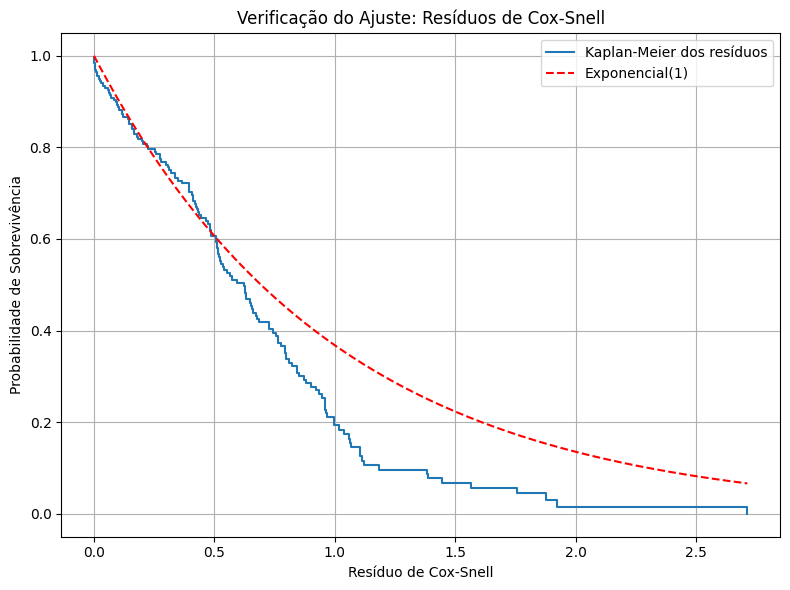

In [104]:
# Resíduos de Cox-Snell

# Calculando a função de sobrevivência estimada para o modelo ajustado
survival_function = aft.predict_survival_function(df[["arrhenius_term_normalized"]])

# Calculando os resíduos de Cox-Snell (baseados na fórmula: -log(S(t)))
residuals_cox_snell = -np.log(survival_function.iloc[:, 0])

# Obter S(t_i | x_i) para cada indivíduo → valor da linha i e coluna i
surv_vals = surv_funcs.to_numpy()[np.arange(len(df_model)), np.arange(len(df_model))]

# Ajustar Kaplan-Meier sobre os resíduos
kmf = KaplanMeierFitter()
kmf.fit(residuals_cox_snell, event_observed=df_model["event"])

# Plotar curva KM dos resíduos vs curva teórica exponencial(1)
plt.figure(figsize=(8, 6))
kmf.plot_survival_function(ci_show=False, label="Kaplan-Meier dos resíduos")

# Curva teórica Exponencial(1): S(t) = exp(-t)
t_vals = np.linspace(0, residuals_cox_snell.max(), 200)
plt.plot(t_vals, np.exp(-t_vals), label="Exponencial(1)", linestyle="--", color="red")

# Gráfico final
plt.title("Verificação do Ajuste: Resíduos de Cox-Snell")
plt.xlabel("Resíduo de Cox-Snell")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



No gráfico, a linha azul (Kaplan-Meier dos resíduos) está próxima, mas abaixo da linha vermelha, indicando que a sobrevivência estimada pelos resíduos é menor do que a esperada pela distribuição exponencial.

Isso sugere que o modelo pode estar subestimando o tempo até o evento em algumas regiões.

O ajuste do modelo não é perfeito, mas a proximidade das linhas indica que o modelo tem um desempenho razoável.

Pequenas discrepâncias podem ser aceitáveis dependendo do contexto e da aplicação.

###Previsão para consições normais de uso: temperturas de 20ºC, 25ºC, 40ºC

###Função de Sobrevivência estimada para condiçoes normais de uso

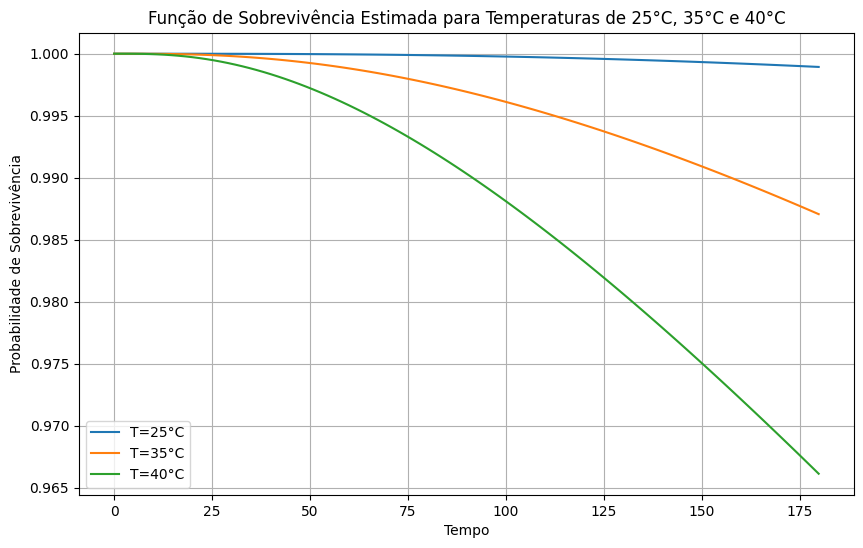

In [106]:
# Normalizando o termo Arrhenius de acordo com os dados usados no modelo ajustado
temperaturas = [25, 35, 40]
previsoes = {}

for temp in temperaturas:
    # Calculando o termo Arrhenius normalizado para a temperatura
    arrhenius_term = 1 / (temp + 273.15)
    arrhenius_term_normalized = (arrhenius_term - df["arrhenius_term"].mean()) / df["arrhenius_term"].std()

    # Previsão da função de sobrevivência para a temperatura
    previsoes[temp] = aft.predict_survival_function(
        pd.DataFrame({"arrhenius_term_normalized": [arrhenius_term_normalized]}),
        times=time_range
    )

# Gráfico das funções de sobrevivência estimadas
plt.figure(figsize=(10, 6))

# Plotando a função de sobrevivência para cada temperatura
for temp in temperaturas:
    survival_estimate = previsoes[temp].iloc[:, 0]
    plt.plot(time_range, survival_estimate, label=f"T={temp}°C")

# Configurações do gráfico
plt.title("Função de Sobrevivência Estimada para Temperaturas de 25°C, 35°C e 40°C")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend()
plt.grid()
plt.show()

Interpretação:

A curva azul (25°C) tem a probabilidade de sobrevivência mais alta ao longo do tempo, indicando que os eventos ocorrem mais lentamente ou com menor risco.

A curva laranja (35°C) mostra uma sobrevivência um pouco menor que a de 25°C, indicando maior risco ou ocorrência mais rápida do evento.

A curva verde (40°C) tem a probabilidade de sobrevivência mais baixa, o que indica que o risco é maior ou os eventos ocorrem mais rapidamente nessa temperatura.

**Conclusão:**

A temperatura influencia a probabilidade de sobrevivência, com temperaturas mais altas reduzindo essa probabilidade ao longo do tempo.

Isso sugere que o aumento da temperatura aumenta o risco ou acelera a ocorrência do evento estudado.

###Tempo médio de vida

In [107]:
for norm_val, temp in zip(inv_temps_norm, temps_celsius):
    mttf = aft.predict_expectation(pd.DataFrame({'arrhenius_term_normalized': [norm_val]}))
    mttf_dias = mttf.values[0]
    mttf_meses = mttf_dias / 30.44  # média de dias por mês
    mttf_anos = mttf_dias / 365.25  # média de dias por ano
    print(f"Temperatura {temp}°C → Tempo médio de vida estimado: {mttf_meses:.2f} meses ({mttf_anos:.2f} anos)")

Temperatura 25°C → Tempo médio de vida estimado: 941.18 meses (78.44 anos)
Temperatura 35°C → Tempo médio de vida estimado: 300.78 meses (25.07 anos)
Temperatura 40°C → Tempo médio de vida estimado: 174.74 meses (14.56 anos)


**CONCLUSÃO**

O modelo Log-Normal estimou tempos médios de vida muito maiores em comparação ao modelo Weibull, sugerindo uma vida útil prolongada para os sistemas analisados.

O modelo log-normal não é o mais adequado para o ajuste dos dados. Apresentou maior AIC e uma análise de residuo nçao muito adequada.

#Modelo Arrhenius-Log-Logístico

###Ajuste do modelo

In [113]:
from lifelines import LogLogisticAFTFitter

# Instanciar o modelo Log-Logístico AFT
aft_loglog = LogLogisticAFTFitter()

# Ajustar o modelo usando a covariável 'arrhenius_term_normalized'
aft_loglog.fit(df, duration_col='time_to_failure', event_col='event', formula="arrhenius_term_normalized")

# Mostrar o resumo do ajuste
aft_loglog.print_summary()


<lifelines.LogLogisticAFTFitter: fitted with 200 total observations, 56 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'event'
   number of observations = 200
number of events observed = 144
           log-likelihood = -553.13
         time fit was run = 2025-08-31 15:59:29 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                  
alpha_ Intercept                  2.72     15.12      0.06            2.60            2.83               13.46               16.97
       arrhenius_term_normalized  0.93      2.54      0.06            0.81            1.06                2.25                2.88
beta_  Intercept                  0.76      2.14      0.07            0.62            0.90                1.87                2.46

                                  cmp to     z      p  -log2(p)
param  covariate                                               
alpha_ Intercept                    0.00 45.90 <0.005       inf
       arrhenius_term_normalized    0.00 14.96 <0.005    165.58
beta_  Intercept                    0.00 10.82 <0.005     88.28
---
Concordance = 0.85
AIC = 1112.27
log-likelihood ratio test = 147.25 on 1 df
-log2(p) of ll-ratio test = 110.15

Intercepto: 2.72
→ Interpretação: Quando a variável preditora (termo de Arrhenius normalizado) é 0 (valor médio), o log do tempo médio até falha é exp(2.72)≈15.12 → Tempo médio estimado ≈ 15.12 dias (no ponto médio da temperatura).

arrhenius_term_normalized: 0.93
→ Interpretação: Cada aumento de 1 unidade no termo de Arrhenius normalizado aumenta o log do tempo de vida em 0.93, o que representa: exp(0.93)≈2.54 dias no tempo de falha

⚠️ Como o termo de Arrhenius é inversamente proporcional à temperatura, temperaturas mais altas → maior arrhenius_term → menor vida útil (porque o termo é normalizado com sinal invertido).

beta_ Forma (Dispersão dos tempos)

Intercepto: 0.76
→ Define a forma da distribuição Log-Logística.
→ Como β<1, indica função de risco decrescente com o tempo, comum em situações onde o risco de falha é maior no início e vai caindo com o tempo.

Significância Estatística

Todos os coeficientes têm p < 0.005 → Significativos.

Intervalos de confiança dos coeficientes não incluem zero, reforçando a significância.

###Função de Sobrevivência

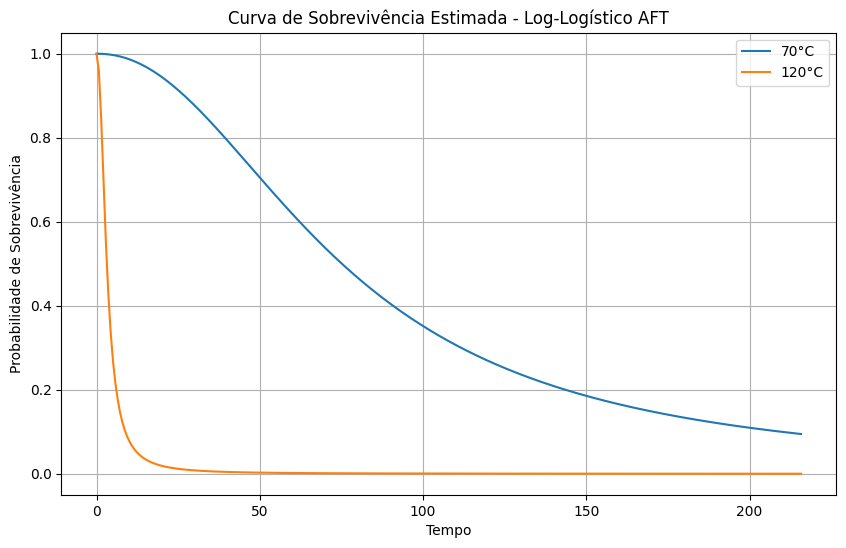

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import LogLogisticAFTFitter

# Temperaturas para análise
temps_celsius = [70, 120]
temps_kelvin = [t + 273.15 for t in temps_celsius]

# Normalizar o termo Arrhenius para essas temperaturas
arrh_mean = df['arrhenius_term'].mean()
arrh_std = df['arrhenius_term'].std()
inv_temps = [1 / t for t in temps_kelvin]
inv_temps_norm = [(x - arrh_mean) / arrh_std for x in inv_temps]

# Definir os tempos para avaliação (pode ajustar o max conforme necessário)
times = np.linspace(0, df['time_to_failure'].max() * 1.2, 300)

plt.figure(figsize=(10, 6))

# Curva de Sobrevivência
plt.subplot(1, 1, 1)
for norm_val, temp in zip(inv_temps_norm, temps_celsius):
    surv = aft_loglog.predict_survival_function(pd.DataFrame({'arrhenius_term_normalized': [norm_val]}), times=times)
    plt.plot(surv.index, surv.values.flatten(), label=f'{temp}°C')

plt.title("Curva de Sobrevivência Estimada - Log-Logístico AFT")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend()
plt.grid(True)

📘 Curva azul – 70°C

Sobrevivência mais longa: a probabilidade de sobrevivência permanece alta por um longo período.

A curva decai de forma mais lenta, indicando que a maioria das unidades sobrevive além de 100 unidades de tempo.

Representa uma condição menos severa (baixa temperatura → menos degradação → vida útil mais longa).

🟧 Curva laranja – 120°C

Queda abrupta na probabilidade de sobrevivência logo no início.

Indica que as unidades falham rapidamente sob essa temperatura mais alta.

A curva praticamente chega a zero antes de 50 unidades de tempo.

**Conclusao:**

O modelo captura corretamente o efeito acelerador da temperatura sobre o tempo de vida.

A temperatura alta (120°C) acelera o processo de falha, enquanto a temperatura baixa (70°C) preserva a integridade dos itens testados.

O comportamento é consistente com o modelo de Arrhenius.

###Função de Risco

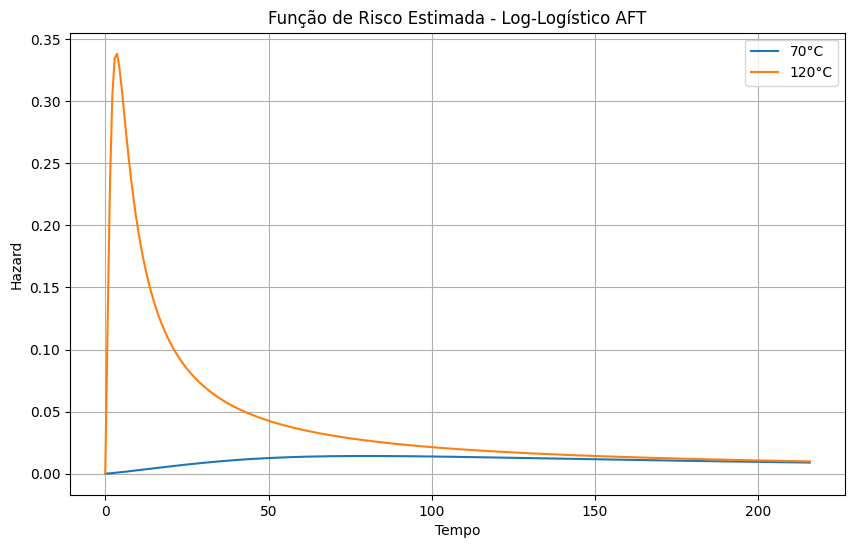

In [126]:
# Função de Risco
plt.figure(figsize=(10, 6))
for norm_val, temp in zip(inv_temps_norm, temps_celsius):
    hazard = aft_loglog.predict_hazard(pd.DataFrame({'arrhenius_term_normalized': [norm_val]}), times=times)
    plt.plot(hazard.index, hazard.values.flatten(), label=f'{temp}°C')

plt.title("Função de Risco Estimada - Log-Logístico AFT")
plt.xlabel("Tempo")
plt.ylabel("Hazard")
plt.legend()
plt.grid(True)


🟧 Curva laranja (120°C)

A função de risco sobe rapidamente no início, atinge um pico e depois decai.

Esse comportamento é típico da distribuição log-logística, que permite risco não-monótono.

A alta temperatura acelera a falha no início (muito perigoso logo no começo).

🔵 Curva azul (70°C)

A função de risco é muito mais suave e baixa em magnitude.

Há um pequeno aumento, mas permanece muito abaixo da curva de 120°C em todo o intervalo.

Mostra que a probabilidade de falha instantânea é baixa durante grande parte do tempo.

**Conclusão:**

O modelo log-logístico com termo de Arrhenius capta bem o efeito acelerador da temperatura.

A forma da curva de risco é não-monótona, como esperado para falhas com envelhecimento e fadiga inicial.

Temperaturas mais altas aumentam o risco de falha logo no início do tempo de uso.

##Validação do Modelo

###Sopreposição da curva de Kaplan-Meier com a curva Teórica do modelo Arrhenius-Log-Logístico

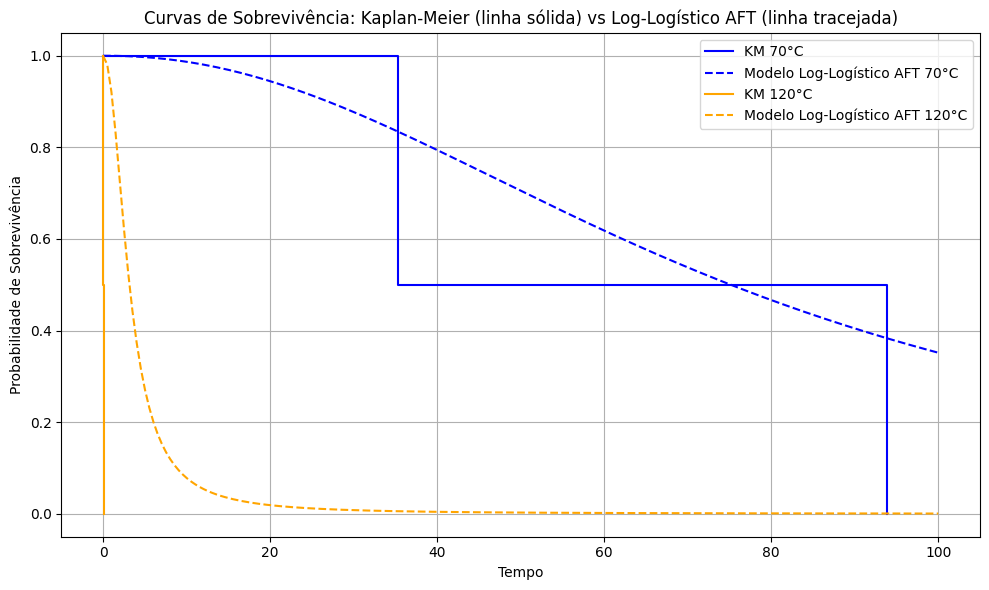

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, LogLogisticAFTFitter


# Calcular média e desvio para normalização do termo Arrhenius (caso ainda não tenha)
arrh_mean = df['arrhenius_term'].mean()
arrh_std = df['arrhenius_term'].std()

# Definir grupos por temperatura observada
grupo_70 = df[(df['temperature_celsius'] >= 69) & (df['temperature_celsius'] <= 71)]
grupo_120 = df[(df['temperature_celsius'] >= 119) & (df['temperature_celsius'] <= 121)]

# Temperaturas para predição
temps = [70, 120]
colors = ['blue', 'orange']

plt.figure(figsize=(10, 6))

for T, grupo, color in zip(temps, [grupo_70, grupo_120], colors):
    # Kaplan-Meier empírica
    kmf = KaplanMeierFitter()
    kmf.fit(grupo['time_to_failure'], event_observed=grupo['event'], label=f'KM {T}°C')
    kmf.plot_survival_function(ci_show=False, color=color, linestyle='-')

    # Termo de Arrhenius normalizado para o modelo
    T_K = T + 273.15
    inv_temp = 1 / T_K
    inv_temp_norm = (inv_temp - arrh_mean) / arrh_std

    # Curva predita pelo modelo
    times = times = np.linspace(0, 100, 200)  # extrapolar um pouco além do max
    surv_pred = aft_loglog.predict_survival_function(
        pd.DataFrame({'arrhenius_term_normalized': [inv_temp_norm]}),
        times=times
    )

    plt.plot(
        surv_pred.index,
        surv_pred.values.flatten(),
        linestyle='--',
        color=color,
        label=f'Modelo Log-Logístico AFT {T}°C'
    )

plt.title("Curvas de Sobrevivência: Kaplan-Meier (linha sólida) vs Log-Logístico AFT (linha tracejada)")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




🔵 70°C

Kaplan-Meier (linha azul sólida): curva empírica com poucos eventos de falha e muitas censuras. A curva é alta por muito tempo, refletindo baixa taxa de falha.

Modelo Log-Logístico AFT (linha azul tracejada): aproxima bem a curva empírica. Pequena divergência no início, mas acompanha bem a tendência geral.

🟠 120°C

Kaplan-Meier (linha laranja sólida): queda abrupta no início. Praticamente todas as falhas ocorrem rapidamente.

Modelo Log-Logístico AFT (linha laranja tracejada): também mostra queda rápida, capturando corretamente a aceleração da degradação com a temperatura.

**Conclusão**

O modelo Log-Logístico AFT com termo de Arrhenius consegue capturar o comportamento diferencial das falhas sob temperaturas distintas.

As curvas ajustadas estão compatíveis com os dados observados, mostrando que o modelo é bem especificado para esse tipo de teste de vida acelerado.

###Resíduos Cox-snell

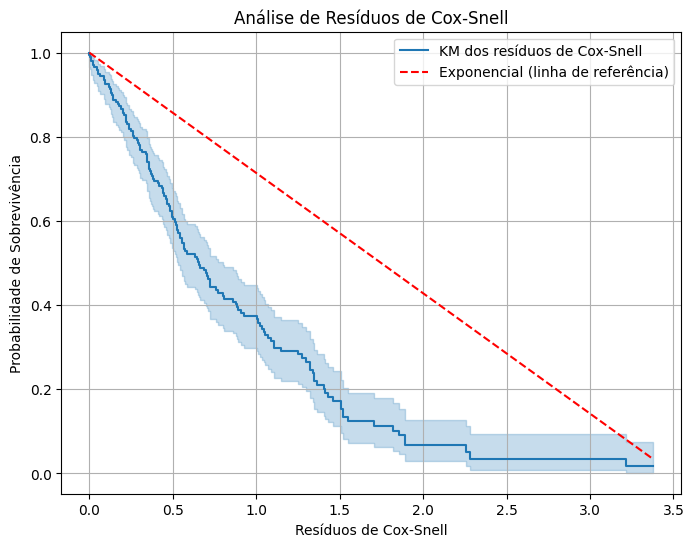

In [131]:
import numpy as np

# Obter as funções de sobrevivência para cada observação no tempo da falha
surv_pred = aft_loglog.predict_survival_function(df, times=df['time_to_failure'])

# Para cada observação, calcular Cox-Snell residual = -log(S(t_i | x_i))
cox_snell_residuals = -np.log(np.diag(surv_pred.values))

# Ajustar Kaplan-Meier nos resíduos para checar ajuste
kmf_cs = KaplanMeierFitter()
kmf_cs.fit(cox_snell_residuals, event_observed=df['event'])

plt.figure(figsize=(8, 6))
kmf_cs.plot_survival_function(label='KM dos resíduos de Cox-Snell')
plt.plot([0, max(cox_snell_residuals)], np.exp(-np.array([0, max(cox_snell_residuals)])), 'r--', label='Exponencial (linha de referência)')
plt.title("Análise de Resíduos de Cox-Snell")
plt.xlabel("Resíduos de Cox-Snell")
plt.ylabel("Probabilidade de Sobrevivência")
plt.legend()
plt.grid(True)
plt.show()


Interpretação do Gráfico
🔹 Curva azul (linha sólida):

Representa a função de sobrevivência empírica (Kaplan-Meier) dos resíduos de Cox-Snell.

🔹 Faixa azul-clara:

Intervalo de confiança para a curva KM.

🔴 Linha tracejada vermelha:

Representa a função de sobrevivência teórica de uma distribuição exponencial(1) — o que os resíduos deveriam seguir se o modelo estivesse perfeitamente ajustado.

A curva KM não aproxima razoavelmente bem da reta exponencial(1), especialmente no início (resíduos menores).

Pequena subestimação da sobrevivência para valores maiores de resíduos (a curva azul cai mais rápido que a vermelha).

Isso pode indicar algum viés ou falta leve de ajuste para tempos maiores, ou influência de censura.

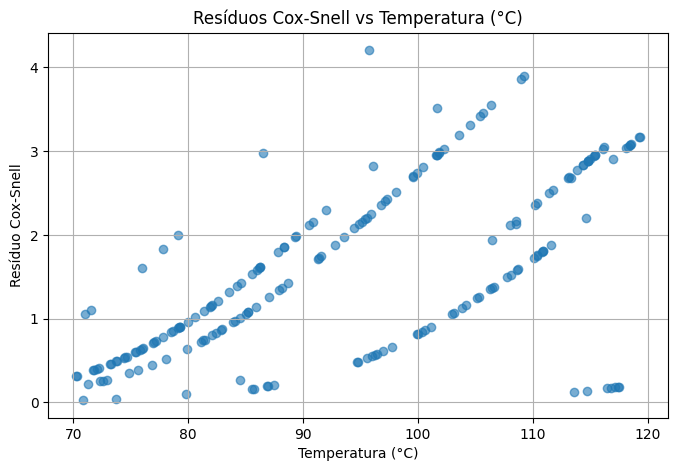

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular a função de sobrevivência estimada para cada indivíduo no seu tempo de falha
surv_funcs = aft_loglog.predict_survival_function(df, times=df['time_to_failure'])

# Extrair a probabilidade de sobrevivência para o tempo de falha de cada indivíduo
# Isso gera uma matriz: linhas = tempos, colunas = indivíduos
# Para pegar o valor correto: para cada indivíduo, pegar a sobrevivência no tempo correspondente

# Como as linhas do DataFrame de saída estão indexadas por tempo, vamos usar o método 'lookup'
# Atenção: método lookup está depreciado, então vamos usar alternativa moderna:

probs_surv = []
for i, t in enumerate(df['time_to_failure']):
    # Encontrar o índice mais próximo do tempo t no índice do DataFrame de sobrevivência
    idx = np.searchsorted(surv_funcs.index.values, t)
    if idx >= len(surv_funcs.index):
        idx = -1  # se extrapolar, pegar último valor
    prob = surv_funcs.iloc[idx, i]
    probs_surv.append(prob)

probs_surv = np.array(probs_surv)

# Calcular resíduos Cox-Snell
residuos_cox_snell = -np.log(probs_surv)

# Agora plotar resíduos versus temperatura
plt.figure(figsize=(8, 5))
plt.scatter(df['temperature_celsius'], residuos_cox_snell, alpha=0.6)
plt.title("Resíduos Cox-Snell vs Temperatura (°C)")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Resíduo Cox-Snell")
plt.grid(True)
plt.show()



Uma tendência muito forte nos resíduos em função da temperatura não deveria ocorrer se o modelo explicasse perfeitamente o efeito da temperatura (via termo Arrhenius).

Isso pode indicar que o modelo não está capturando 100% da relação temperatura → tempo de falha.

**Conclusão:**

O modelo parece capturar parcialmente o efeito da temperatura, mas ainda restam padrões sistemáticos nos resíduos.

Isso viola a suposição de que os resíduos devem ser independentes da covariável.

É um sinal de que:

Talvez seja necessário incluir mais termos (não-lineares).

**O modelo Arrheniu-Log-Logístico não é indicado para fazer extrapolação para as condições normais de uso**